In [1]:
#| default_exp topology

In [ ]:
#| export

import numpy as np
import igl

In [ ]:
#| hide

import matplotlib.pyplot as plt

In [3]:
#| export

import jax
import jax.numpy as jnp

In [4]:
#| export

from jaxtyping import Int, Bool 
from typing import Any

import dataclasses

import functools

In [5]:
#| export

from triangulax import trigonometry as trig
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
import triangulax.mesh as msh
from triangulax import geometry as geom

In [6]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [7]:
#| hide

import jaxtyping


In [8]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, disable type checks

## Topological modifications in half-edge meshes

We often need to not only move the vertices of a mesh, but modify the connectivity. In half-edge meshes, there are several "elementary" mesh modifications.
For `triangulax`, by far the most important one is the edge flip (see below). It is the only modification that preserves the number of all mesh elements, and is thus relatively easy to make compatible with JAX and differentiable programming.

**Design note**: for JIT-compatibility, none of the topology modification functions (`flip_edge`, `collapse_edge`, `split_vertex`) check in advance whether they will produce a valid mesh.  Separate predicate functions (`can_flip_edge`, `can_collapse_edge`, `can_split_vertex`) are provided for this purpose: call them before the modification if you need to guard against invalid operations.

### Edge flips / T1s

In our simulations, cells will exchange neighbors (T1-event). In the triangulation, this corresponds to an edge flip. We now implement the edge flip algorithm for `HeMesh`es. We basically edit the various connectivity arrays (in a JAX-compatible way).

The algorithm (and the naming conventions in `flip_edge`) are from [here](https://jerryyin.info/geometry-processing-algorithms/half-edge/).

**Before**

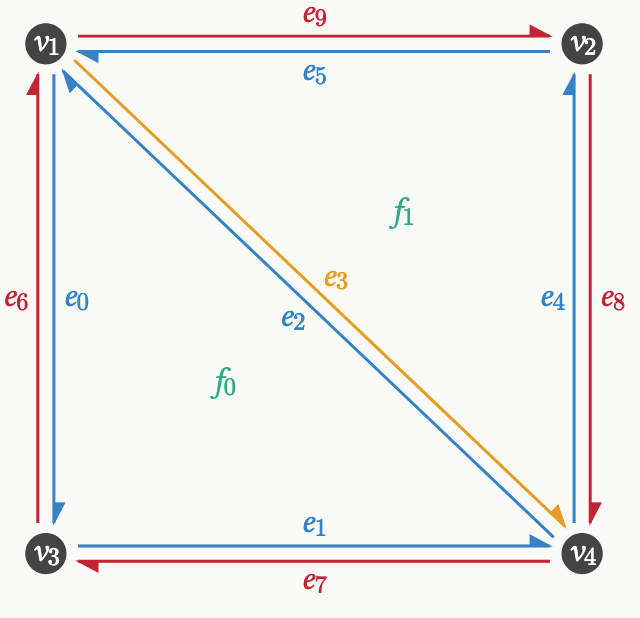

**After**

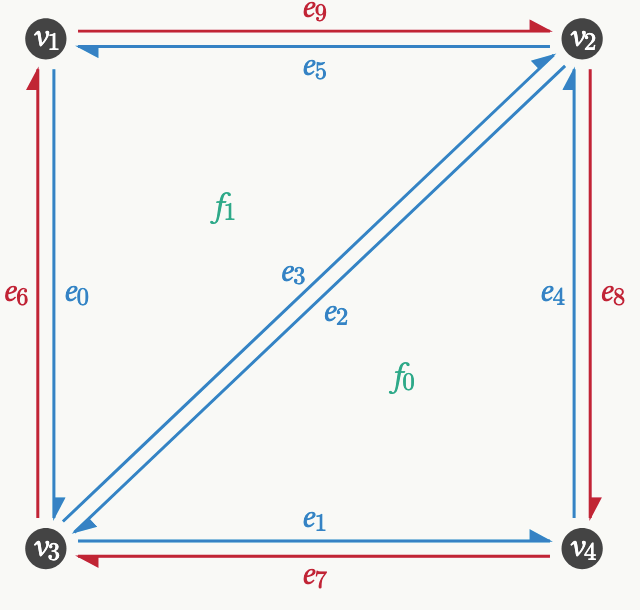

In [9]:
#| export

@functools.partial(jax.jit, static_argnames=['check_boundary'])
def flip_edge(hemesh: HeMesh, e: Int[jax.Array, ""], check_boundary: bool = False) -> HeMesh:
    """
    Flip half-edge e in a half-edge mesh.
    
    See https://jerryyin.info/geometry-processing-algorithms/half-edge/. The algorithm
    is slightly modified since we keep track of the origin and destination of a half-edge,
    and use arrays instead of pointers. Returns a new HeMesh, does not modify in-place.

    Does not check whether the flip produces a valid mesh. Use `can_flip_edge` to check first.
    """
    if check_boundary:
        assert (hemesh.heface[e] !=-1 and hemesh.heface[hemesh.twin[e]] != -1), "Cannot flip boundary edge"

    # identify relevant elements
    e5 = hemesh.prv[e]
    e4 = hemesh.nxt[e]
    twin = hemesh.twin[e]
    e1 = hemesh.prv[twin] 
    e0 = hemesh.nxt[twin] 

    # make sure there's no vertex or face references to e or twin
    incident = hemesh.incident.at[jnp.array([hemesh.orig[e], hemesh.orig[twin]])].set(
        jnp.array([hemesh.twin[e5], hemesh.twin[e1]]))
    face_incident = hemesh.face_incident.at[jnp.array([hemesh.heface[e], hemesh.heface[twin]])].set(
        jnp.array([e5, e1])) # e1, e5 don't change face

    # update the data structure to do the T1
    nxt = hemesh.nxt.at[jnp.array([e, twin])].set(jnp.array([e5, e1]))
    prv = hemesh.prv.at[jnp.array([e, twin])].set(jnp.array([e0, e4]))
    orig = hemesh.orig.at[jnp.array([e, twin])].set(jnp.array([hemesh.orig[e1], hemesh.orig[e5]]) )
    dest = hemesh.dest.at[jnp.array([e, twin])].set(jnp.array([hemesh.dest[e4], hemesh.dest[e0]]))

    nxt = nxt.at[jnp.array([e0, e1, e4, e5])].set(jnp.array([e, e4, twin, e0]) )
    prv = prv.at[jnp.array([e0, e1, e4, e5])].set(jnp.array([e5, twin, e1, e]) )
    heface = hemesh.heface.at[jnp.array([e0, e4])].set(jnp.array([hemesh.heface[e5], hemesh.heface[e1]]))

    return HeMesh(incident, orig, dest, hemesh.twin, nxt, prv, heface, face_incident, hemesh.inf_vertices)

In [10]:
#| export

@jax.jit
def can_flip_edge(hemesh: HeMesh, e: Int[jax.Array, ""]) -> Bool[jax.Array, ""]:
    """
    Check whether flipping half-edge e would produce a valid mesh.
    
    An edge can be flipped if it is interior (not boundary) and the two opposite vertices
    are not already connected (which would create a duplicate edge).
    """
    twin = hemesh.twin[e]
    is_interior = (hemesh.heface[e] != -1) & (hemesh.heface[twin] != -1)
    # opposite vertices after flip
    v_opp_1 = hemesh.dest[hemesh.nxt[e]]     # = orig of prv[e]
    v_opp_2 = hemesh.dest[hemesh.nxt[twin]]   # = orig of prv[twin]
    # check that v_opp_1 and v_opp_2 are not already connected
    already_connected = jnp.any((hemesh.orig == v_opp_1) & (hemesh.dest == v_opp_2))
    return is_interior & ~already_connected

In [11]:
mesh = TriMesh.read_obj("../test_meshes/disk.obj")
hemesh = HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
geommesh = GeomMesh(*hemesh.n_items, mesh.vertices, mesh.face_positions)

  o flat_tri_ecmc


(np.float64(-1.10003475),
 np.float64(1.09628575),
 np.float64(-1.09934025),
 np.float64(1.09050125))

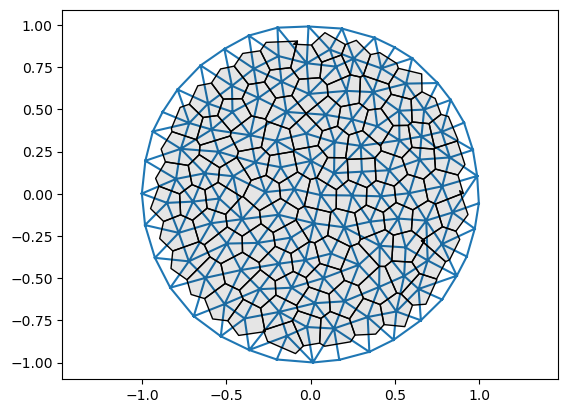

In [12]:
plt.triplot(*geommesh.vertices.T, hemesh.faces)
ax = plt.gca()
p = msh.cellplot(hemesh, geommesh.face_positions,
                 cell_colors=np.array([0,0,0,0.1]), mpl_polygon_kwargs={"lw": 1, "ec": "k"})
plt.gca().add_collection(p)

plt.axis("equal")

In [13]:
# flip edge and recompute face positions

flipped_hemesh = flip_edge(hemesh, e=335)
flipped_geommesh = geom.set_voronoi_face_positions(geommesh, flipped_hemesh)

In [14]:
# connectivity is still valid

igl.is_edge_manifold(hemesh.faces)[0], igl.is_edge_manifold(flipped_hemesh.faces)[0], flipped_hemesh.iterate_around_vertex(100)

(True, True, Array([298, 299, 630, 632], dtype=int64))

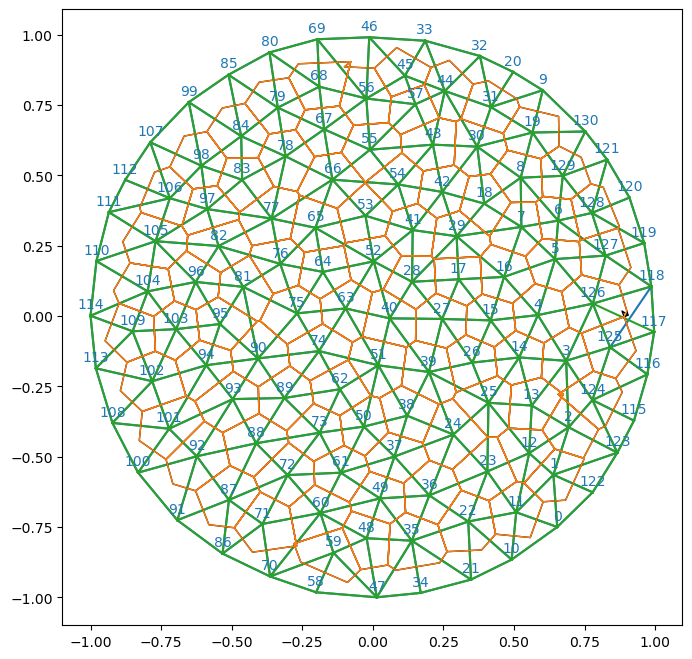

In [15]:
# you can see the flipped edge between vertices 126-117 in the plot below (middle right)

fig = plt.figure(figsize=(8,8))

plt.triplot(*geommesh.vertices.T, hemesh.faces)
plt.triplot(*flipped_geommesh.vertices.T, flipped_hemesh.faces)

ax = plt.gca()
p1 = msh.cellplot(hemesh, geommesh.face_positions,
         cell_colors=np.array([0.,0.,0.,0.]), mpl_polygon_kwargs={"lw": 1, "ec": "k"})
p2 = msh.cellplot(flipped_hemesh, flipped_geommesh.face_positions,
              cell_colors=np.array([0.,0.,0.,0.]), mpl_polygon_kwargs={"lw": 1, "ec": "tab:orange"})
ax.add_collection(p1)
ax.add_collection(p2)
plt.axis("equal")

msh.label_plot(geommesh.vertices, hemesh.faces, fontsize=10, face_labels=False)

#### Repeated flips

In a simulation, we need to carry out edge flips at every time step. The function `flip_edge` does a single edge flip by modifying the connectivity arrays, and is already JIT-compatible.

To carry out multiple flips, we must do them in sequence (otherwise, you risk leaving the mesh in an invalid state). The simplest approach is `flip_all`, which does a `jax.lax.scan` over _all_ half-edges. This is JIT-compatible because the scan length is fixed (= number of half-edges), but can be slow for large meshes since it visits every edge even if only a few need flipping.

A more efficient alternative is `flip_n_shortest`, which sorts edges by length, selects the `max_flips` shortest candidates, and scans only over those. This is significantly faster (e.g., 100–110 μs for 10 flips vs. 600 μs for a full scan on a typical mesh). The `max_flips` parameter is a static argument: changing it triggers recompilation, but within a simulation it is typically constant. See `tutorials/03_vertex_models` for a full usage example with per-edge cooldowns.

In [16]:
mesh = TriMesh.read_obj("../test_meshes/disk.obj")
hemesh = HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
geommesh = GeomMesh(*hemesh.n_items, mesh.vertices, mesh.face_positions)

  o flat_tri_ecmc


In [26]:
from jaxtyping import Float

def get_oriented_dual_he_length(vertices: Float[jax.Array, "n_vertices 2"],
                                face_positions: Float[jax.Array, "n_faces 2"],
                                hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Compute lengths of dual edges. Boundary dual edges get length 1. Negative sign = flipped edge."""
    dual_edges = face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]]

    edges = vertices[hemesh.orig]-vertices[hemesh.dest]
    edges_normalized = (edges.T / jnp.linalg.norm(edges, axis=-1)).T
    signed_dual_length = jnp.einsum('vi,vi->v', edges_normalized,
                                    dual_edges @ trig.get_rot_mat(-jnp.pi/2))
    signed_dual_length = jnp.where(hemesh.is_bdry_edge, 1, signed_dual_length)
    return signed_dual_length

In [27]:
from importlib import reload
reload(geom)

<module 'triangulax.geometry' from '/Users/nc1333/Documents/Princeton/Coding/triangulax/triangulax/geometry.py'>

In [28]:
# let's detect all edges with negative dual length, and flip them.

dual_lengths = geom.get_oriented_dual_he_length(geommesh.vertices, geommesh.face_positions, hemesh)
edges = jnp.where((dual_lengths < 0.0) & ~hemesh.is_bdry_edge & hemesh.is_unique)[0]
# we only want to flip unique hes!
edges, edges.size

(Array([  9, 185, 191, 335], dtype=int64), 4)

In [30]:
#| export

@jax.jit
def flip_by_id(hemesh: HeMesh, ids: Int[jax.Array, " flips"], to_flip: Bool[jax.Array, " flips"]) -> HeMesh:
    """Flip half-edges from ids array where to_flip is True. Wraps flip_edge."""
    def scan_fun(h, x):
        return jax.lax.cond(x[1], lambda hh: flip_edge(hh, x[0]), lambda hh: hh, h), None
    xs = jnp.stack([ids, to_flip], axis=1)  
    flipped_hemesh, _ = jax.lax.scan(scan_fun, init=hemesh, xs=xs)
    return flipped_hemesh

@jax.jit
def flip_all(hemesh: HeMesh, to_flip: Bool[jax.Array, " n_hes"]) -> HeMesh:
    """
    Flip all (unique) half-edges where to_flip is True in a half-edge mesh. Wraps flip_edge.
    
    Note: scans over *all* half-edges, which can be slow for large meshes. See `flip_n_shortest`
    for a more efficient alternative that only scans over a fixed number of candidate edges.
    """
    def scan_fun(h, e):
        return jax.lax.cond(to_flip[e] & hemesh.is_unique[e],
                            lambda hh: flip_edge(hh, e), lambda hh: hh, h), None
    flipped_hemesh, _ = jax.lax.scan(scan_fun, init=hemesh, xs=jnp.arange(hemesh.n_hes) )
    return flipped_hemesh

In [31]:
#| export

@functools.partial(jax.jit, static_argnames=['max_flips'])
def flip_n_shortest(hemesh: HeMesh, edge_lengths: Int[jax.Array, " n_hes"],
                    threshold: float, max_flips: int = 10) -> tuple[HeMesh, Bool[jax.Array, " n_hes"]]:
    """
    Flip up to `max_flips` shortest edges below `threshold`.

    Sorts edges by length, selects the `max_flips` shortest unique, non-boundary candidates,
    and flips those below `threshold`. Much faster than `flip_all` for large meshes.

    Parameters
    ----------
    hemesh : HeMesh
        The half-edge mesh.
    edge_lengths : Float[Array, " n_hes"]
        Per-half-edge edge lengths (e.g., dual/Voronoi edge lengths).
    threshold : float
        Edges shorter than this are flipped.
    max_flips : int
        Maximum number of edges to consider. Static argument (changing it triggers recompilation).

    Returns
    -------
    hemesh : HeMesh
        The mesh after flipping.
    did_flip : Bool[Array, " n_hes"]
        Boolean mask of half-edges that were flipped.
    """
    lengths = jnp.where(hemesh.is_unique & ~hemesh.is_bdry_edge, edge_lengths, jnp.inf)
    ids = jnp.argsort(lengths)[:max_flips]
    hemesh_new = flip_by_id(hemesh, ids, lengths[ids] < threshold)
    did_flip = (lengths < threshold) & (lengths <= lengths[ids[max_flips - 1]])
    return hemesh_new, did_flip

In [32]:
to_flip = (dual_lengths < 0) & ~jnp.isnan(dual_lengths)

flipped_hemesh = flip_all(hemesh, to_flip=to_flip)

In [33]:
igl.is_edge_manifold(flipped_hemesh.faces)[0], igl.is_vertex_manifold(flipped_hemesh.faces)[0]

(True, np.True_)

In [34]:
flipped_hemesh = flip_all(hemesh, to_flip=(dual_lengths<0.02)) # no extra recompile

In [35]:
flipped_geommesh = geom.set_voronoi_face_positions(geommesh, flipped_hemesh)

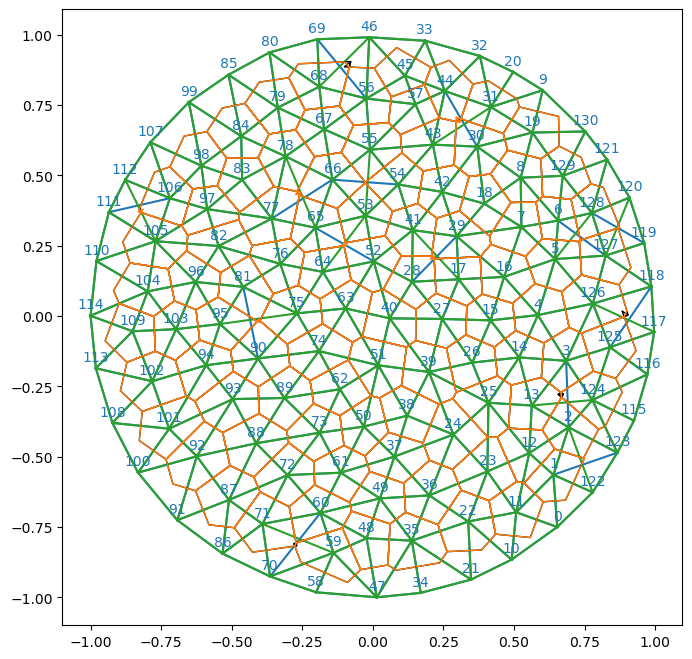

In [36]:
fig = plt.figure(figsize=(8,8))

plt.triplot(*geommesh.vertices.T, hemesh.faces)
plt.triplot(*flipped_geommesh.vertices.T, flipped_hemesh.faces)

ax = plt.gca()
p1 = msh.cellplot(hemesh, geommesh.face_positions,
         cell_colors=np.array([0.,0.,0.,0.]), mpl_polygon_kwargs={"lw": 1, "ec": "k"})
p2 = msh.cellplot(flipped_hemesh, flipped_geommesh.face_positions,
              cell_colors=np.array([0.,0.,0.,0.]), mpl_polygon_kwargs={"lw": 1, "ec": "tab:orange"})
ax.add_collection(p1)
ax.add_collection(p2)
plt.axis("equal")

msh.label_plot(geommesh.vertices, hemesh.faces, fontsize=10, face_labels=False)

### Splitting and collapsing vertices 

The edge flip is the only topological modification of a half-edge mesh that leaves the number of vertices, edges, and faces constant. This makes it especially easy, and compatible with JAX's "static array size" paradigm.

However, we may also want to simulate processes (like cell division or death) where the number of cells _does_ change. We implement two elementary operations, which are inverses of one another: **edge collapse** and **vertex split**.

To **collapse** a half-edge `e` in a `hemesh`:

1. Delete faces `hemesh.heface[e]`, `hemesh.heface[hemesh.twin[e]]`
2. Delete all the half-edges in those faces.
3. Glue the "gap" back together.
4. Merge the vertices `hemesh.orig[e]`,  `hemesh.dest[e]`

We must be careful to preserve the manifold structure of the mesh and deal with edge cases. We test the resulting half-edge mesh via plots and use `libigl` to verify that the mesh is in a valid state.

We also need a data structure (`MeshReindexMap`) to keep track of how vertices/edges/faces of the initial mesh map to those of the modified one.

In [33]:
%unload_ext jaxtyping

In [34]:
#| export

def remap_inds_removal_forward(N: int, removed: Int[jax.Array, " n_removed"]) -> Int[jax.Array, " N"]:
    """Remap indices after removal. Returns array arr[i] = i - (removed < i).sum()."""
    remap = jnp.arange(N)
    return remap - jnp.searchsorted(jnp.sort(removed), remap, side='left')  # left


def remap_inds_removal_reverse(N: int, removed: Int[jax.Array, " n_removed"]) -> Int[jax.Array, " N-n_removed"]:
    """Remap indices after removal. Reverse of remap_inds_removal_forward."""
    remap = jnp.arange(N)
    return jnp.delete(remap, removed, assume_unique_indices=True)


In [35]:
#| export

@jax.tree_util.register_dataclass
@dataclasses.dataclass(frozen=True)
class MeshReindexMap:
    """Old↔new index maps produced by topology-changing operations."""
    v_forward: Int[jax.Array, " n_vertices_old"]
    v_reverse: Int[jax.Array, " n_vertices_new"]
    f_forward: Int[jax.Array, " n_faces_old"]
    f_reverse: Int[jax.Array, " n_faces_new"]
    he_forward: Int[jax.Array, " n_hes_old"]
    he_reverse: Int[jax.Array, " n_hes_new"]
    info: dict[str, Any] = dataclasses.field(default_factory=dict, metadata=dict(static=True))


In [36]:
N = 10
removed = jnp.array([5, 2])
forward = remap_inds_removal_forward(N, removed)
reverse = remap_inds_removal_reverse(N, removed)

forward[6], reverse[2], jnp.allclose(forward[reverse], jnp.arange(N - removed.shape[0]))    

(Array(4, dtype=int64), Array(3, dtype=int64), Array(True, dtype=bool))

In [26]:
#| export

@jax.jit
def can_collapse_edge(hemesh: HeMesh, e: Int[jax.Array, ""]) -> Bool[jax.Array, ""]:
    """
    Check whether collapsing half-edge e would produce a valid mesh (link condition).
    
    An edge can be collapsed if it is interior and the two endpoint vertices share exactly
    two common neighbors (the opposite vertices of the two adjacent faces). This is the
    discrete "link condition" that ensures the collapse preserves manifoldness.
    """
    t = hemesh.twin[e]
    is_interior = (hemesh.heface[e] != -1) & (hemesh.heface[t] != -1)
    # compute neighbor sets via orig/dest
    v0, v1 = hemesh.orig[e], hemesh.dest[e]
    nbrs_v0 = jnp.where(hemesh.orig == v0, hemesh.dest, -1)
    nbrs_v1 = jnp.where(hemesh.orig == v1, hemesh.dest, -1)
    # count common neighbors (a neighbor n is common if it appears in both nbr sets)
    is_common = jnp.any(nbrs_v0[:, None] == nbrs_v1[None, :], axis=1) & (nbrs_v0 != -1)
    n_common = jnp.sum(is_common)
    return is_interior & (n_common == 2)

In [37]:
#| export

@functools.partial(jax.jit, static_argnames=['check_boundary']) 
def collapse_edge(hemesh: HeMesh, e: int, check_boundary=False
                  ) -> tuple[HeMesh, MeshReindexMap]:
    """
    Collapse half-edge e in a half-edge mesh. Keeps the origin vertex of e.
        
    Returns a new HeMesh (does not modify in-place), and a MeshReindexMap for remapping
    vertex, half-edge, and face indices from the original mesh to the new mesh.

    Does not check whether the collapse produces a valid mesh. Use `can_collapse_edge` to check first.

    JIT-compatible, but calling with different numbers of vertices/edges/faces will cause recompilation.
    """

    if check_boundary:
        assert not hemesh.is_bdry_edge[e] and not hemesh.is_inf_he[e], "Interior edges only"

    # identify relevant elements
    t = hemesh.twin[e]

    # make sure there's no vertex references to e or twin
    incident = hemesh.incident.at[jnp.array([hemesh.orig[e], # v1 
                                             hemesh.orig[hemesh.prv[e]], # v2
                                             hemesh.orig[hemesh.prv[t]]])].set( # v4
                                  jnp.array([hemesh.twin[hemesh.prv[e]],
                                             hemesh.twin[hemesh.nxt[e]],
                                             hemesh.twin[hemesh.nxt[t]]]))
    # re-twin the half-edges
    twin = hemesh.twin.at[jnp.array([hemesh.twin[hemesh.prv[e]],
                                     hemesh.twin[hemesh.nxt[e]], 
                                     hemesh.twin[hemesh.prv[t]],
                                     hemesh.twin[hemesh.nxt[t]]])].set( 
                          jnp.array([hemesh.twin[hemesh.nxt[e]],
                                     hemesh.twin[hemesh.prv[e]],
                                     hemesh.twin[hemesh.nxt[t]],
                                     hemesh.twin[hemesh.prv[t]]]))
    # edit orign and dest for all hes in/out of v3
    orig = jnp.where(hemesh.orig==hemesh.dest[e], hemesh.orig[e], hemesh.orig)
    dest = jnp.where(hemesh.dest==hemesh.dest[e], hemesh.orig[e], hemesh.dest)

    # delete the elements
    v_delete = jnp.array([hemesh.dest[e]])
    hes_delete = jnp.array([e, hemesh.nxt[e], hemesh.prv[e],
                            t, hemesh.nxt[t], hemesh.prv[t]])
    fs_delete =  jnp.array([hemesh.heface[e], hemesh.heface[t]])
    incident = jnp.delete(incident, v_delete, assume_unique_indices=True)
    face_incident = jnp.delete(hemesh.face_incident, fs_delete, assume_unique_indices=True)
    
    def delete_he(arr): return jnp.delete(arr, hes_delete, assume_unique_indices=True)
    orig, dest = (delete_he(orig), delete_he(dest))
    twin = delete_he(twin)
    nxt, prv = (delete_he(hemesh.nxt), delete_he(hemesh.prv))
    heface = delete_he(hemesh.heface)

    # index remapping: identity for v < hemesh.dest[e], v-> v-1 for
    remap_v = remap_inds_removal_forward(hemesh.n_vertices, v_delete)
    remap_he = remap_inds_removal_forward(hemesh.n_hes, hes_delete)  
    remap_f = remap_inds_removal_forward(hemesh.n_faces, fs_delete)

    index_map = MeshReindexMap(v_forward=remap_v,
                               v_reverse=remap_inds_removal_reverse(hemesh.n_vertices, v_delete),
                               f_forward=remap_f,
                               f_reverse=remap_inds_removal_reverse(hemesh.n_faces, fs_delete),
                               he_forward=remap_he,
                               he_reverse=remap_inds_removal_reverse(hemesh.n_hes, hes_delete),
                               info={"operation": "collapse_edge", "collapsed_edge": e})
    
    inf_vertices = tuple(int(remap_v[v]) for v in hemesh.inf_vertices)

    # special case: boundary hes need "-1" face
    is_bdry_he = jnp.delete(hemesh.heface == -1, hes_delete, assume_unique_indices=True)
    heface = jnp.where(is_bdry_he, -1, remap_f[heface])

    new_hemesh = HeMesh(incident=remap_he[incident], orig=remap_v[orig], dest=remap_v[dest],
                        twin=remap_he[twin], nxt=remap_he[nxt], prv=remap_he[prv],
                        heface=heface, face_incident=remap_he[face_incident], inf_vertices=inf_vertices)

    return new_hemesh, index_map

In [38]:
# test on the existing example mesh. pick some interior, unique half-edge

candidates = np.where(np.asarray(hemesh.is_unique & (~hemesh.is_bdry_edge)))[0]
e_collapse = candidates[40]
print("Collapsing half-edge", e_collapse, "with vertices", int(hemesh.orig[e_collapse]), int(hemesh.dest[e_collapse]))

hemesh_collapsed, remap = collapse_edge(hemesh, e_collapse,)
vertices_collapsed =  geommesh.vertices[remap.v_reverse]


Collapsing half-edge 42 with vertices 8 129


In [39]:
hemesh, hemesh_collapsed # removes 1 vertex, 6 half-edges, and 2 faces

(HeMesh(N_V=131, N_HE=708, N_F=224), HeMesh(N_V=130, N_HE=702, N_F=222))

In [40]:
# stil valid mesh
(msh.test_mesh_validity(hemesh_collapsed), igl.is_edge_manifold(hemesh_collapsed.faces)[0],
 igl.is_vertex_manifold(hemesh_collapsed.faces)[0])

(True, True, np.True_)

In [41]:
%timeit _ = collapse_edge(hemesh, e_collapse,)

44.8 μs ± 5.34 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


(np.float64(-1.10003475),
 np.float64(1.09628575),
 np.float64(-1.09934025),
 np.float64(1.09050125))

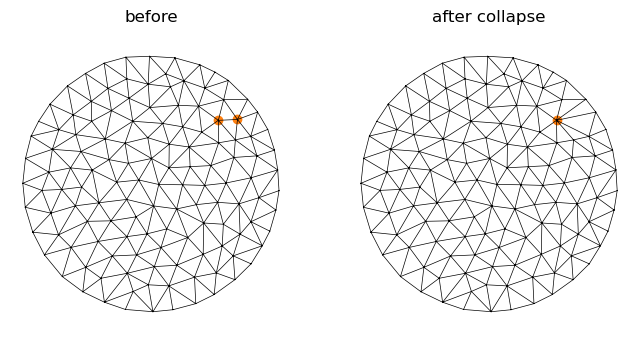

In [43]:
# visualize before/after
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

plt.sca(ax[0])
v1, v2 = (hemesh.orig[e_collapse], hemesh.dest[e_collapse])
plt.scatter(*geommesh.vertices[v1], c="tab:orange")
plt.scatter(*geommesh.vertices[v2], c="tab:orange")
plt.triplot(np.asarray(geommesh.vertices)[:, 0], np.asarray(geommesh.vertices)[:, 1], np.asarray(hemesh.faces), lw=0.5, color="k")
plt.title("before")
plt.axis("equal")
plt.axis("off")

plt.sca(ax[1])
plt.scatter(*geommesh.vertices[v1], c="tab:orange")
plt.triplot(np.asarray(vertices_collapsed)[:, 0], np.asarray(vertices_collapsed)[:, 1],
            np.asarray(hemesh_collapsed.faces), lw=0.5, color="k")
plt.title("after collapse")
plt.axis("equal")
plt.axis("off")

#### Split vertex ("cell division")

The opposite of edge collapse: splitting a vertex into two. We specify two half-edges (the "splitting axis") that originate at a common vertex. Like before, we need a `MeshReindexMap` tracking how old and new mesh elements are related. New elements are appended at the end of the arrays.

In [44]:
#| export

def can_split_vertex(hemesh: HeMesh, e1: int, e2: int) -> bool:
    """
    Check whether splitting a vertex along half-edges e1 and e2 is valid.
    
    Both half-edges must originate from the same vertex, and both must be on interior faces.
    """
    return (hemesh.orig[e1] == hemesh.orig[e2] and
            hemesh.heface[e1] != -1 and hemesh.heface[e2] != -1 and e1 != e2)

In [45]:
#| export

def split_vertex(hemesh: HeMesh, e1: int, e2: int, check_args: bool=False) -> tuple[HeMesh, MeshReindexMap]:
    """
    Split a vertex into two along a "splitting axis" given by two half-edges originating at that vertex.
    
    New vertex inserted at origin of e2. The new vertex will be the final one in the array.

    This function is not JIT-compatible, since it depends on iterating around the vertex to update origins/destinations.
    """
    if check_args:
        assert hemesh.orig[e1]==hemesh.orig[e2] and not hemesh.heface[e1]==-1 and not hemesh.heface[e2]==-1, "invalid half edges"

    # create 1 new vertex, 6 new half-edges, and 2 new faces. By convention, at the end of the arrays
    incident = jnp.pad(hemesh.incident, (0, 1))
    face_incident = jnp.pad(hemesh.face_incident, (0, 2))
    orig, dest, twin, nxt, prv, heface = [jnp.pad(arr, (0, 6))
                                         for arr in [hemesh.orig, hemesh.dest, hemesh.twin, hemesh.nxt, hemesh.prv, hemesh.heface]]

    # the new elements are appended at the end
    vnew = hemesh.n_vertices
    fnew_1, fnew_2 = hemesh.n_faces, hemesh.n_faces+1 # faces of triangle of twin[e1] and triangle of twin[e2]
    enew_1, enew_2, enew_3 = hemesh.n_hes, hemesh.n_hes+1, hemesh.n_hes+2 # fnew_1, enew_1 is twin[e1]
    enew_4, enew_5, enew_6 = hemesh.n_hes+3, hemesh.n_hes+4, hemesh.n_hes+5 # fnew_2, enew_4 is twin[e2]

    # set incidents for new mesh elements
    incident = incident.at[vnew].set(e2)
    incident = incident.at[hemesh.orig[e1]].set(e1)  # ensure original vertex still points to a valid outgoing he
    heface = heface.at[jnp.array([enew_1, enew_2, enew_3])].set(fnew_1)
    heface = heface.at[jnp.array([enew_4, enew_5, enew_6])].set(fnew_2)
    face_incident = face_incident.at[jnp.array([fnew_1, fnew_2])].set(jnp.array([enew_1, enew_4]))

    # origin and destination of new half-edges
    orig = orig.at[jnp.array([enew_1, enew_2, enew_3])].set(jnp.array([hemesh.dest[e1], hemesh.orig[e1], vnew]))
    orig = orig.at[jnp.array([enew_4, enew_5, enew_6])].set(jnp.array([hemesh.dest[e2], vnew, hemesh.orig[e1]]))
    dest = dest.at[jnp.array([enew_1, enew_2, enew_3])].set(jnp.array([hemesh.orig[e1], vnew, hemesh.dest[e1]]))
    dest = dest.at[jnp.array([enew_4, enew_5, enew_6])].set(jnp.array([vnew, hemesh.orig[e1], hemesh.dest[e2]]))
    
    # nxt, prv, twin of new half-edges
    nxt = nxt.at[jnp.array([enew_1, enew_2, enew_3])].set(jnp.array([enew_2, enew_3, enew_1]))
    nxt = nxt.at[jnp.array([enew_4, enew_5, enew_6])].set(jnp.array([enew_5, enew_6, enew_4]))
    prv = prv.at[jnp.array([enew_1, enew_2, enew_3])].set(jnp.array([enew_3, enew_1, enew_2]))
    prv = prv.at[jnp.array([enew_4, enew_5, enew_6])].set(jnp.array([enew_6, enew_4, enew_5]))
    
    twin = twin.at[jnp.array([enew_1, enew_2, enew_3])].set(jnp.array([e1, enew_5, hemesh.twin[e1]]))
    twin = twin.at[jnp.array([enew_4, enew_5, enew_6])].set(jnp.array([e2, enew_2, hemesh.twin[e2]]))
    twin = twin.at[jnp.array([e1, e2])].set(jnp.array([enew_1, enew_4]))
    twin = twin.at[jnp.array([hemesh.twin[e1], hemesh.twin[e2]])].set(jnp.array([enew_3, enew_6]))

    # finally, need to update the origin and destination of half-edges into the "split" vertex.
    # iterate around the vertex from e2 to e1 to get the ones we need to update
    outgoing = [e2]
    while True:
        next_edge = hemesh.twin[hemesh.prv[outgoing[-1]]]
        if next_edge == e1:
            break
        outgoing.append(next_edge)
    outgoing = jnp.array(outgoing)
    orig = orig.at[outgoing].set(vnew)
    dest = dest.at[hemesh.prv[outgoing]].set(vnew)

    # no need to update the indices, since we appended the mesh elements at the very end
    new_hemesh = HeMesh(incident=incident, orig=orig, dest=dest, twin=twin, nxt=nxt, prv=prv,
                        heface=heface, face_incident=face_incident, inf_vertices=hemesh.inf_vertices)
    
    # need to find the "parents" of the new mesh elements
    v_reverse = jnp.arange(hemesh.n_vertices+1).at[vnew].set(hemesh.orig[e1])
    f_reverse = jnp.arange(hemesh.n_faces+2).at[jnp.array([fnew_1, fnew_2])].set(
                                                jnp.array([hemesh.heface[e1], hemesh.heface[e2]]))
    he_reverse = jnp.arange(hemesh.n_hes+6)
    he_reverse = he_reverse.at[jnp.array([enew_1, enew_2, enew_3])].set(
                              jnp.array([e1, e1, hemesh.twin[e1]]))
    he_reverse = he_reverse.at[jnp.array([enew_4, enew_5, enew_6])].set(
                              jnp.array([e2, e2, hemesh.twin[e2]]))
    index_map = MeshReindexMap(v_forward=jnp.arange(hemesh.n_vertices),
                               v_reverse=v_reverse,
                               f_forward=jnp.arange(hemesh.n_faces),
                               f_reverse=f_reverse,
                               he_forward=jnp.arange(hemesh.n_hes),
                               he_reverse=he_reverse,
                               info={"operation": "split_vertex", "split_edges": (e1, e2), "new_vertex": vnew})

    return new_hemesh, index_map

In [46]:
# test split on the existing example mesh

# choose an interior vertex (avoid boundary) and two outgoing half-edges for split axis
v_split = jnp.where(~hemesh.is_bdry)[0][10]
v_new = hemesh.n_vertices  # new vertex index

ring = hemesh.iterate_around_vertex(v_split)
h1 = int(ring[0])
h2 = int(ring[len(ring)//2])
print("Splitting vertex", v_split, "axis hes", h1, h2)

hemesh_split, smap = split_vertex(hemesh, h1, h2)
print("Old:", hemesh, "new:", hemesh_split)

Splitting vertex 13 axis hes 56 407
Old: HeMesh(N_V=131, N_HE=708, N_F=224) new: HeMesh(N_V=132, N_HE=714, N_F=226)


In [47]:
assert hemesh_split.n_vertices == hemesh.n_vertices + 1
assert hemesh_split.n_hes == hemesh.n_hes + 6
assert hemesh_split.n_faces == hemesh.n_faces + 2

F_split = np.asarray(hemesh_split.faces, dtype=np.int32)
print("edge manifold:", igl.is_edge_manifold(F_split)[0])
print("vertex manifold:", igl.is_vertex_manifold(F_split)[0])
print("Valid HE mesh:", msh.test_mesh_validity(hemesh_split))

edge manifold: True
vertex manifold: True
Valid HE mesh: True


In [48]:
# inverse consistency check: split then collapse the inserted edge
e_join = hemesh.n_hes+1 # error for  2*hemesh.n_vertices+1 ?
hemesh_back, back_map = collapse_edge(hemesh_split, e_join)

F0 = msh._canonical_faces_np(hemesh.faces)
F_back = msh._canonical_faces_np(hemesh_back.faces)
print("back to original counts?", hemesh_back.n_items == hemesh.n_items)
print("back to original faces?", np.array_equal(F0, F_back))
print("Valid HE mesh after collapse:", msh.test_mesh_validity(hemesh_back))

back to original counts? True
back to original faces? True
Valid HE mesh after collapse: True


In [49]:
# offset the new vertex slightly for visibility

vertices_split = np.concatenate([geommesh.vertices, geommesh.vertices[v_split][None, :]], axis=0)
d = trig.get_perp_2d(geommesh.vertices[hemesh.dest[h1]] - geommesh.vertices[hemesh.dest[h2]])

eps = 0.2
vertices_split[v_new] = vertices_split[v_new] +  eps * d
vertices_split[v_split] = vertices_split[v_split] - eps * d

vertices_collapsed =  vertices_split[back_map.v_reverse]

(np.float64(-1.10003475),
 np.float64(1.09628575),
 np.float64(-1.09934025),
 np.float64(1.09050125))

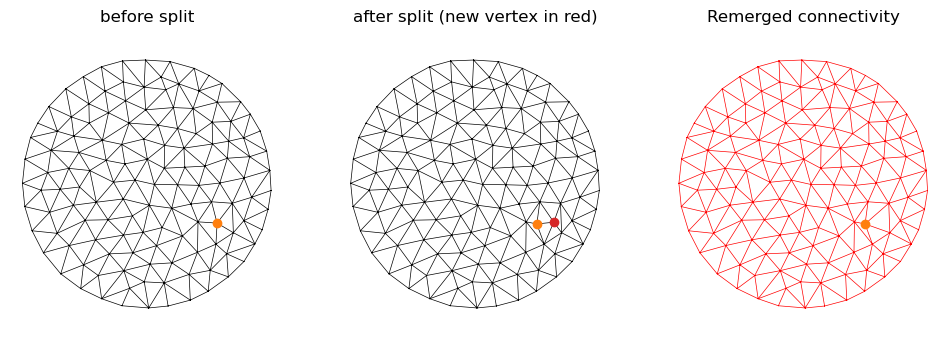

In [50]:
# quick visualization (triangulation plot)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

plt.sca(ax[0])
plt.triplot(*geommesh.vertices.T, hemesh.faces, lw=0.5, color="k")
plt.scatter(*geommesh.vertices[v_split], c="tab:orange")
plt.title("before split")
plt.axis("equal"); plt.axis("off")

plt.sca(ax[1])
plt.triplot(*vertices_split.T, hemesh_split.faces, lw=0.5, color="k")
plt.scatter(*vertices_split[v_split], c="tab:orange")
plt.scatter(*vertices_split[v_new], c="tab:red")
plt.title("after split (new vertex in red)")
plt.axis("equal"); plt.axis("off")

plt.sca(ax[2])
plt.triplot(*vertices_collapsed.T, hemesh_back.faces, lw=0.5, color="r")
plt.scatter(*vertices_split[v_split], c="tab:orange")
plt.title("Remerged connectivity")
plt.axis("equal"); plt.axis("off")

### Not yet implemented

The following topological operations are not yet available in `triangulax`:

- **Edge split**: insert a new vertex on an existing edge, splitting it and both adjacent faces. (Distinct from vertex split above.)
- **Edge contraction with boundary support**: the current `collapse_edge` only handles interior edges.
- **Batch collapse / split**: JIT-compatible routines for performing multiple collapses or splits per time step, analogous to `flip_all` / `flip_n_shortest` for edge flips.
- **Vertex removal**: remove a vertex and re-triangulate the resulting hole.